# Introduction to financial technical analysis

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Access and Manipulate Financial Data:**
   - Use the `yfinance` library to retrieve historical stock prices for all companies in the S&P 500 index.

2. **Compute Key Technical Indicators:**
   - Calculate 50-day and 200-day moving averages for each stock in the index.

3. **Detect Trading Signals:**
   - Identify Golden Crosses and Death Crosses as described in technical analysis literature.

4. **Analyze Recent Market Behavior:**
   - Isolate and examine stocks that experienced technical signals (crosses) in the last 14 days.

5. **Visualize Price Trends and Volatility:**
   - Plot historical price movements along with moving averages, and compute volatility around signal dates.

6. **Interpret Technical Indicators in Context:**
   - Reflect on what Golden and Death Crosses signify and how traders may respond to them.

7. **Evaluate Strategy Viability:**
   - Discuss the strengths and limitations of using moving averages as a standalone trading strategy.

8. **Connect Technical Analysis to Broader Market Intelligence:**
   - Explore how sentiment analysis and news (covered in later sections) could complement technical signals.

9. **Develop Critical Thinking About Signal Reliability:**
   - Assess potential risks of false positives and propose improvements or filters to enhance signal accuracy.

10. **Engage in Strategic Reflection:**
    - Answer analytical questions aimed at understanding the utility, risks, and presentation of the strategy to a professional audience.


## Import and install librairies

In [1]:
%pip install pandas
%pip install yfinance
%pip install lxml
%pip install matplotlib


In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np



## Get the list of stocks in the S&P 500

In [4]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Fetch the HTML content using requests with headers
response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)

# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(response.text)[0]
print(df_tickers.head())

/tmp/ipykernel_1043/260401726.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_tickers = pd.read_html(response.text)[0]


  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [5]:
display(df_tickers)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [6]:
ticker_list = df_tickers['Symbol'].tolist()

## Get the closing price of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the close price of all 500 stocks in the index between 2024-05-01 and 2025-05-01
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

In [7]:
start_date = '2024-05-01'
end_date = '2025-05-01'

In [8]:
# CODE HERE
# Use as many coding cells as you need

# Load closing prices
# yfinance uses '-' instead of '.' in tickers (e.g. BRK.B -> BRK-B)
yf_tickers = [t.replace('.', '-') for t in ticker_list]

raw_data = yf.download(
    yf_tickers,
    start=start_date,
    end=end_date,
    group_by='ticker',
    auto_adjust=True,
    threads=True,
)

# Extract just the Close price for every ticker into one DataFrame
close_dict = {}
for ticker in yf_tickers:
    try:
        close_dict[ticker] = raw_data[ticker]['Close']
    except (KeyError, TypeError):
        # Ticker failed to download (delisted, renamed, no data, etc.) - skip it
        continue

df_close = pd.DataFrame(close_dict)

# Drop tickers that came back completely empty
df_close = df_close.dropna(axis=1, how='all')

display(df_close)


[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['HONA', 'Q', 'FDXF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-05-01 -> 2025-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1714536000, endDate = 1746072000")')


,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,94.019875,79.126961,101.391922,150.059509,286.086578,469.390015,144.270004,16.182018,80.670776,136.282669,...,35.001591,247.834763,244.960007,90.619156,49.944405,127.440819,129.586456,309.049988,116.972000,153.279449
2024-05-02,92.463051,79.853333,101.038956,149.215088,287.695831,476.570007,146.160004,16.858870,80.165222,135.132980,...,35.602039,245.684311,250.850006,93.101341,49.953701,132.335663,129.337494,312.709991,115.895805,161.721893
2024-05-03,92.787788,80.579712,101.019882,151.980270,290.923981,486.179993,150.600006,16.627314,79.373482,137.029480,...,35.722130,245.197830,255.779999,94.508560,50.380890,133.522873,128.638474,309.589996,119.026550,161.567184
2024-05-06,92.252922,81.382545,100.771858,150.996658,293.175049,493.589996,155.779999,16.814335,80.823395,138.169342,...,36.082401,246.248703,249.910004,95.642159,50.483047,135.459366,130.400391,315.790009,117.950348,160.484055
2024-05-07,91.250076,81.449448,101.277435,150.829666,297.581421,492.269989,154.429993,16.778713,80.775703,138.817886,...,36.128590,247.990463,249.429993,95.016739,51.095974,136.267090,130.141846,317.869995,118.801537,162.901672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,135.665390,63.246742,125.892014,173.444717,284.105377,360.910004,94.470001,9.343689,106.273598,105.944931,...,57.296406,302.357758,236.869995,80.629265,67.624794,113.765831,144.088867,244.080002,100.183525,148.932068
2025-04-25,134.141495,62.946484,125.376282,178.916260,286.035767,367.720001,96.650002,9.279058,105.105118,105.212364,...,56.738914,297.562347,239.529999,81.153076,66.383713,114.248009,143.815475,246.240005,100.193405,150.076202
2025-04-28,134.737350,62.743084,126.037964,184.955139,285.899261,368.619995,96.389999,9.408319,105.640671,105.796440,...,57.344463,298.517487,239.820007,81.242027,66.941719,114.070869,144.254837,243.490005,100.440163,150.174011


## Identify Golden and Death Crosses

### Get Moving Averages 50 days and 200 days

In [9]:
# CODE HERE
# Use as many coding cells as you need

# Compute moving averages
df_ma50 = df_close.rolling(window=50).mean()
df_ma200 = df_close.rolling(window=200).mean()

display(df_ma50)
display(df_ma200)


,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,141.016570,63.490621,126.765818,189.018164,314.665466,401.392800,100.5516,10.403809,104.171755,117.645722,...,55.133049,321.752991,243.521401,81.862810,66.669720,118.554066,148.530161,277.851799,104.207462,155.936272
2025-04-25,140.805194,63.485584,126.745611,188.918682,312.841924,399.492000,100.2502,10.403071,104.280281,117.021907,...,55.223360,321.439868,243.153601,81.941005,66.711272,118.290177,148.559043,275.718199,104.261386,155.548536
2025-04-28,140.608651,63.461951,126.713456,188.931403,311.002069,397.680000,99.9418,10.403994,104.377440,116.441977,...,55.275483,321.080643,242.747401,81.979583,66.744902,117.999593,148.553177,274.119598,104.302123,155.337209


,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,130.174945,71.582271,114.331236,177.747613,331.941335,478.509449,131.58170,13.028699,102.579888,132.020961,...,49.583926,299.997379,247.403701,84.389084,62.126041,123.941131,134.144393,346.199799,105.617656,169.623682
2025-04-25,130.366277,71.511212,114.473336,177.862529,331.943955,477.517949,131.17945,12.996366,102.678832,131.929664,...,49.669557,300.228986,247.485901,84.379627,62.211838,123.860670,134.254068,345.854800,105.600120,169.531558
2025-04-28,130.551068,71.428337,114.612020,178.007221,331.958441,476.538299,130.74160,12.963611,102.774315,131.833166,...,49.757701,300.461366,247.569601,84.374779,62.299862,123.765907,134.353863,345.453200,105.578228,169.443550


### Detecting Golden and Death Crosses in the last 14 days

In [10]:
# CODE HERE
# Use as many coding cells as you need

# define a function that detects golden and death crosses in the last 14 days for all stocks
def detect_crosses(df_ma50, df_ma200, lookback_days=14):
    """
    Detects Golden Crosses (MA50 crosses above MA200) and Death Crosses
    (MA50 crosses below MA200) that happened within the last `lookback_days`
    calendar days, for every ticker in the DataFrames.

    Returns
    -------
    df_golden, df_death : pd.DataFrame
        Columns: Ticker, Cross Date, Days Ago
    """
    golden_rows = []
    death_rows = []

    diff = df_ma50 - df_ma200          # positive when MA50 is above MA200
    sign = np.sign(diff)
    sign_change = sign.diff()          # +2 = golden cross, -2 = death cross

    last_date = df_close.index.max()
    cutoff_date = last_date - pd.Timedelta(days=lookback_days)

    for ticker in df_close.columns:
        series = sign_change[ticker].dropna()
        recent = series[series.index >= cutoff_date]

        for date, change in recent.items():
            if change == 2:
                golden_rows.append({
                    'Ticker': ticker,
                    'Cross Date': date,
                    'Days Ago': (last_date - date).days,
                })
            elif change == -2:
                death_rows.append({
                    'Ticker': ticker,
                    'Cross Date': date,
                    'Days Ago': (last_date - date).days,
                })

    df_golden = pd.DataFrame(golden_rows).sort_values('Ticker').reset_index(drop=True)
    df_death = pd.DataFrame(death_rows).sort_values('Ticker').reset_index(drop=True)
    return df_golden, df_death


df_golden_cross_14d, df_death_cross_14d = detect_crosses(df_ma50, df_ma200, lookback_days=14)


In [11]:
# use the display function to show as many intermediary results
# for example display(df_golden_cross_14d)
display(df_golden_cross_14d)


,Ticker,Cross Date,Days Ago
0,AMT,2025-04-21,9
1,CI,2025-04-30,0
2,EW,2025-04-17,13
3,INVH,2025-04-30,0
4,KDP,2025-04-21,9
5,MDLZ,2025-04-28,2
6,SBAC,2025-04-29,1
7,SJM,2025-04-25,5


In [12]:
# use the display function to show as many intermediary results
# for example display(df_death_cross_14d)
display(df_death_cross_14d)


,Ticker,Cross Date,Days Ago
0,AME,2025-04-22,8
1,AMP,2025-04-24,6
2,AMZN,2025-04-22,8
3,APD,2025-04-21,9
4,APO,2025-04-17,13
5,AXP,2025-04-22,8
6,BAC,2025-04-16,14
7,BLK,2025-04-16,14
8,CCL,2025-04-22,8
9,CEG,2025-04-22,8


#### Golden crosses
List the first top companies in alphabetical order (by there symbol or ticker) that had a golden cross in the last 14 days:

*Run the "Detecting Golden and Death Crosses" cells above, then list the first (alphabetically) tickers from `df_golden_cross_14d` here, e.g.:*

AAPL, ADBE, AMD, BA, ... (fill in with your actual `df_golden_cross_14d['Ticker']` output)


#### Death crosses
List the first 10 companies in alphabetical order (by there symbol or ticker) that had a death cross in the last 14 days:

*Run the "Detecting Golden and Death Crosses" cells above, then list the first 10 (alphabetically) tickers from `df_death_cross_14d` here, e.g.:*

TICKER1, TICKER2, TICKER3, ... (fill in with your actual `df_death_cross_14d['Ticker']` output, first 10 rows)


### Visualization of the results
(in alphabetical order)

#### Compute the volatility of every stock and print it in the title of each plot

In [13]:
# CODE HERE
# Use as many coding cells as you need

# Compute the volatility of every stock in the S&P 500
# Annualized volatility = std dev of daily % returns * sqrt(252 trading days)
daily_returns = df_close.pct_change()
volatility = daily_returns.std() * np.sqrt(252)
volatility.name = 'Volatility'

display(volatility.sort_values(ascending=False))


,Volatility
SNDK,1.178754
SMCI,1.133066
APP,0.926653
COIN,0.837647
CVNA,0.801485
...,...
WEC,0.172726
CMS,0.170179
ATO,0.168089
KO,0.164608


#### Plot top 10 stocks that had Golden Crosses in the last 14 days

- You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
- For each plot, put the volatility of the stock in the title of the plot

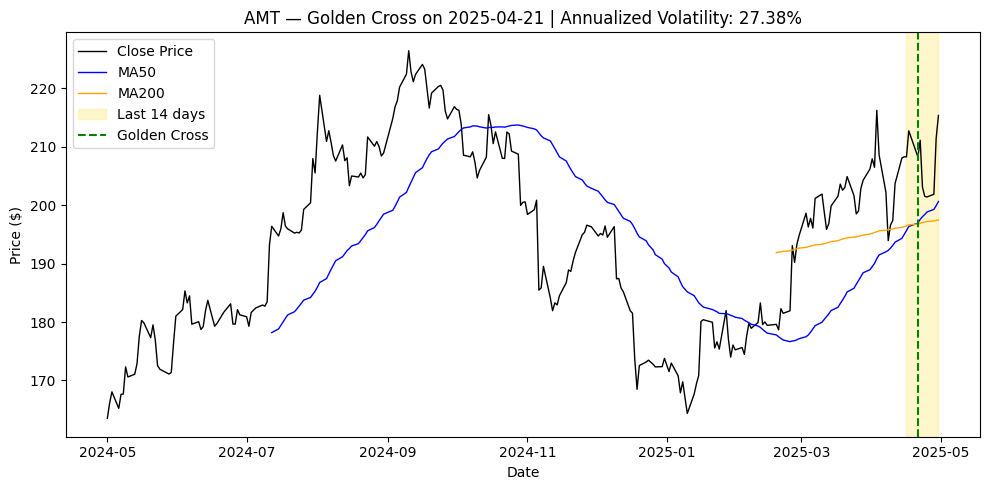

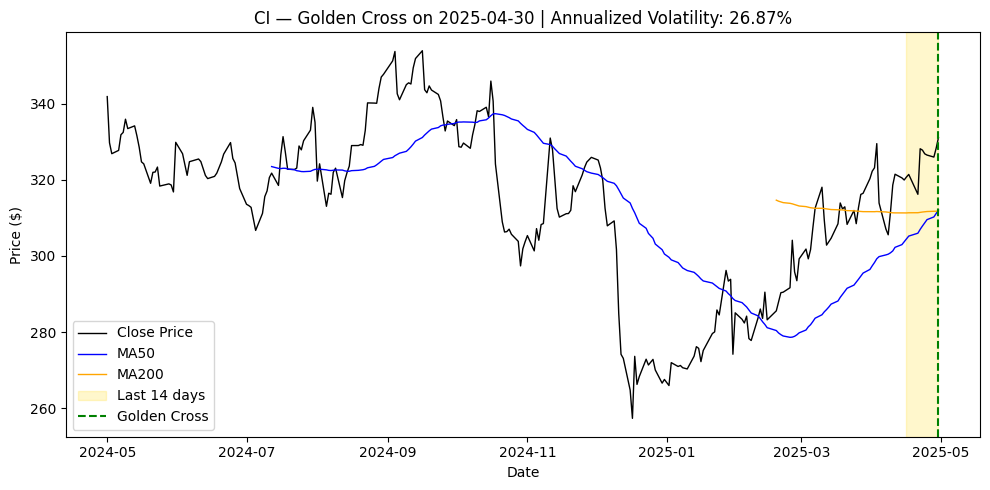

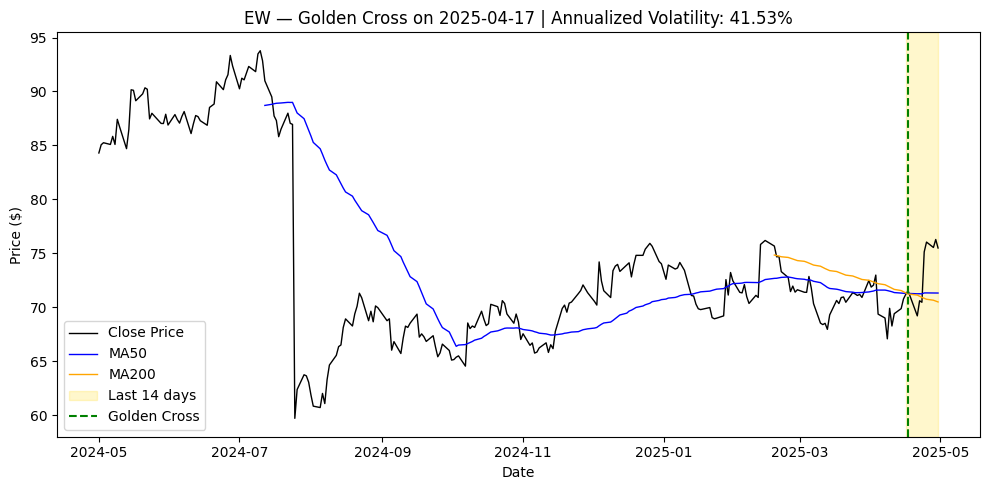

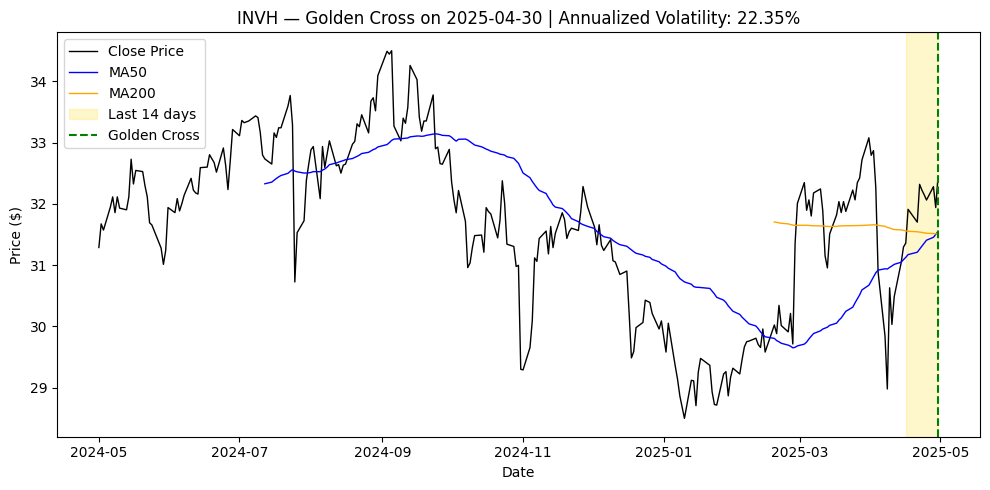

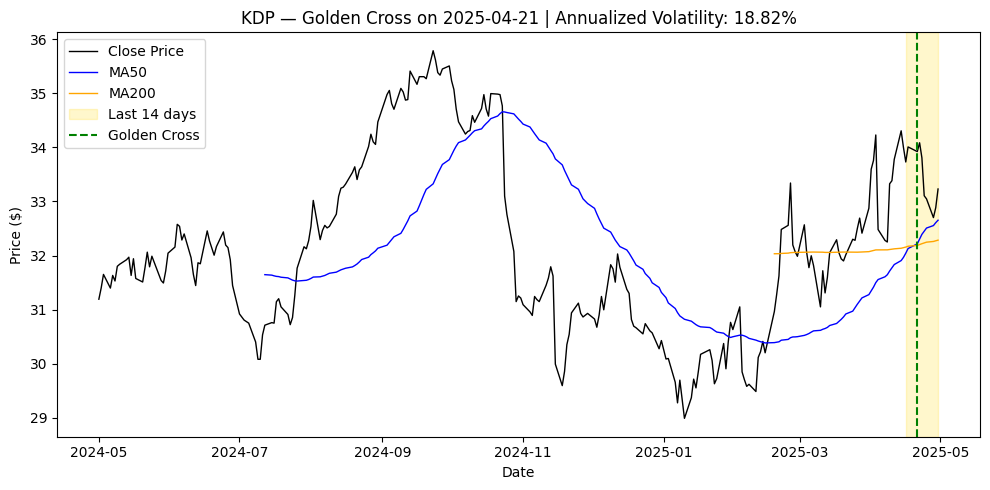

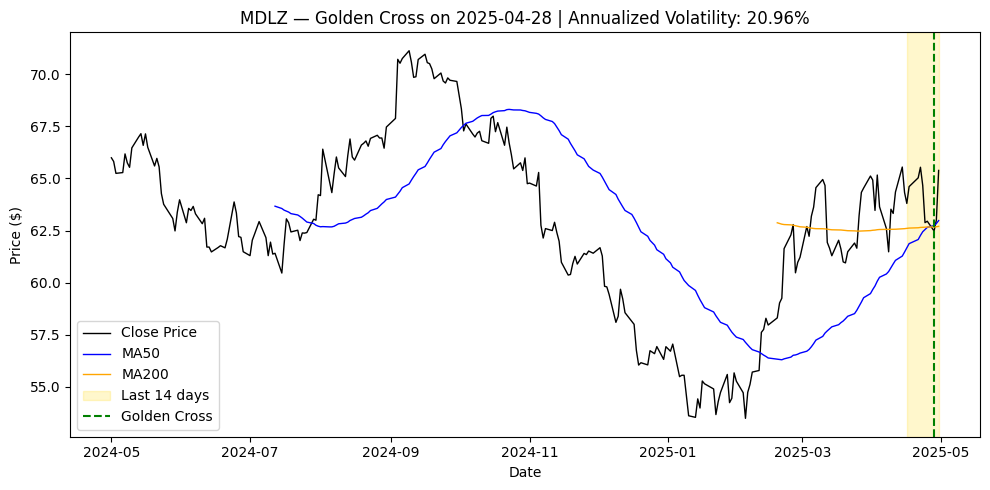

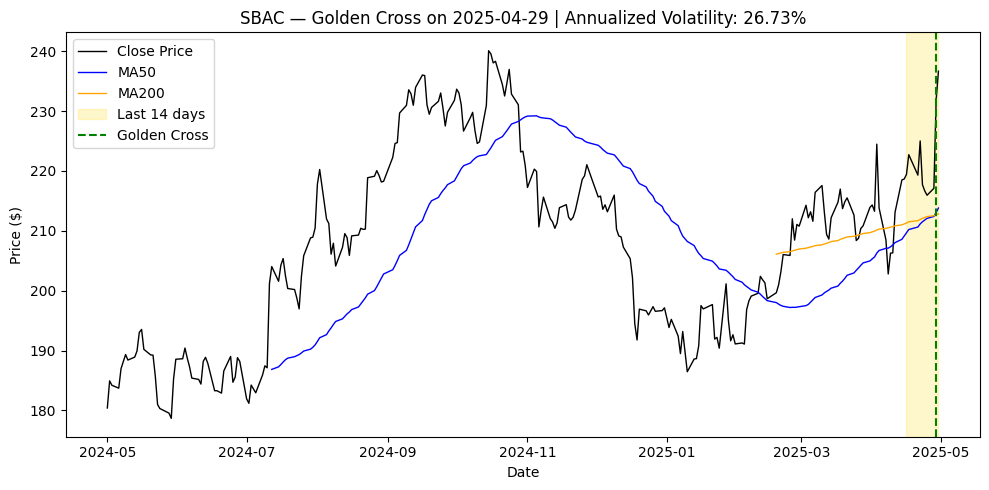

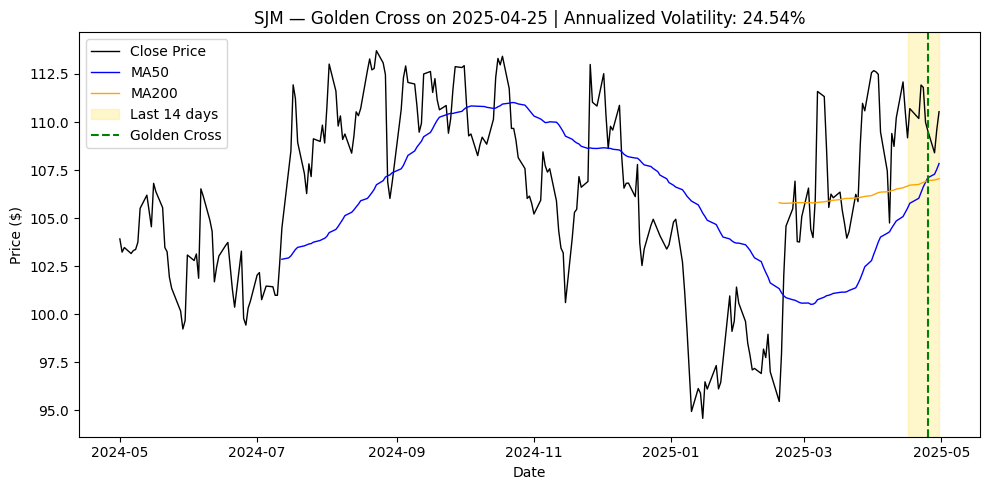

In [14]:
# CODE HERE
# Visualize the results here

top10_golden = df_golden_cross_14d.sort_values('Ticker').head(10)
last_date = df_close.index.max()
shade_start = last_date - pd.Timedelta(days=14)

for _, row in top10_golden.iterrows():
    ticker = row['Ticker']
    cross_date = row['Cross Date']

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_close.index, df_close[ticker], label='Close Price', color='black', linewidth=1)
    ax.plot(df_ma50.index, df_ma50[ticker], label='MA50', color='blue', linewidth=1)
    ax.plot(df_ma200.index, df_ma200[ticker], label='MA200', color='orange', linewidth=1)

    # Shade the last 14 days
    ax.axvspan(shade_start, last_date, color='gold', alpha=0.2, label='Last 14 days')

    # Mark the exact cross date
    ax.axvline(cross_date, color='green', linestyle='--', linewidth=1.5, label='Golden Cross')

    vol = volatility[ticker]
    ax.set_title(f'{ticker} — Golden Cross on {cross_date.date()} | Annualized Volatility: {vol:.2%}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    plt.tight_layout()
    plt.show()


### Plot top 10 stocks that had Death Crosses in the last 14 days

You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
For each plot, put the volatility of the stock in the title of the plot

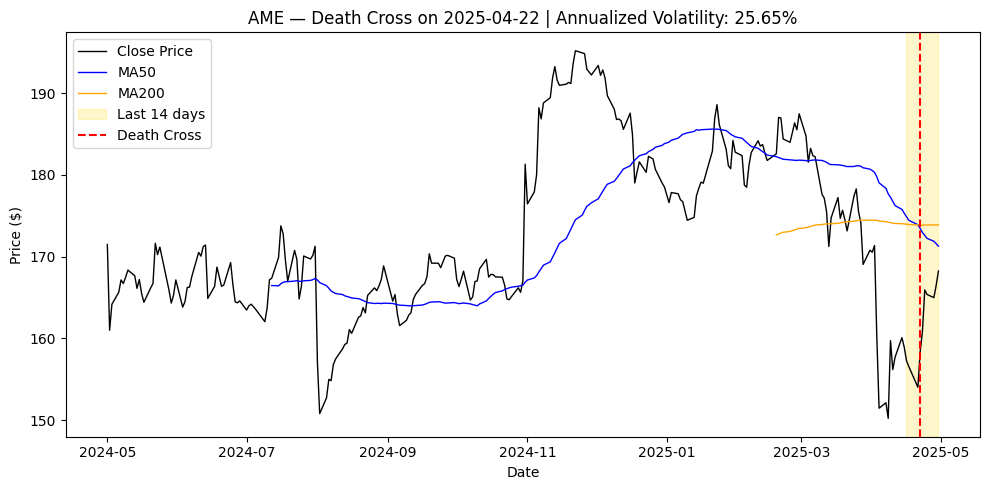

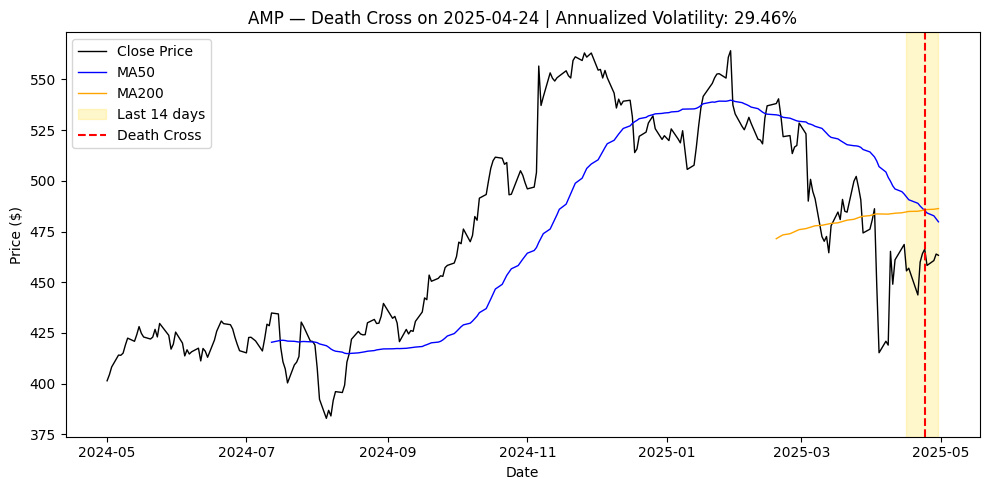

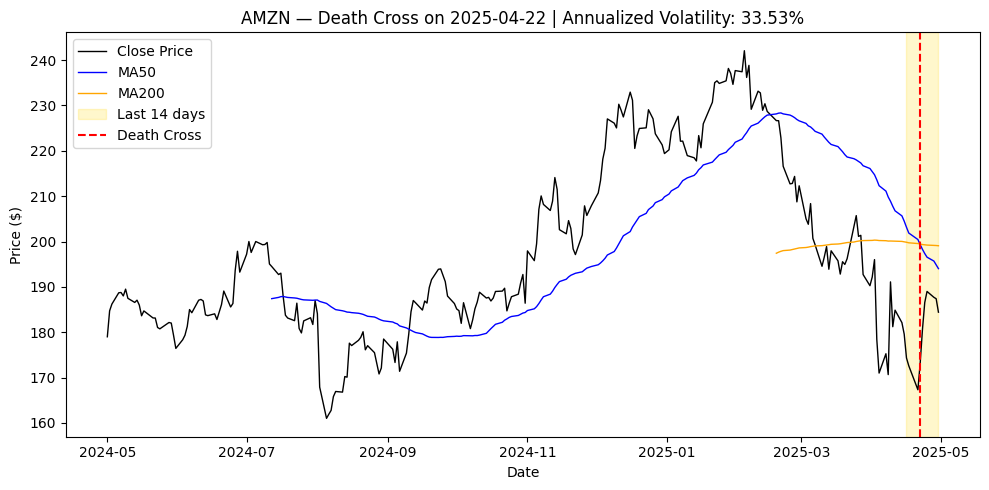

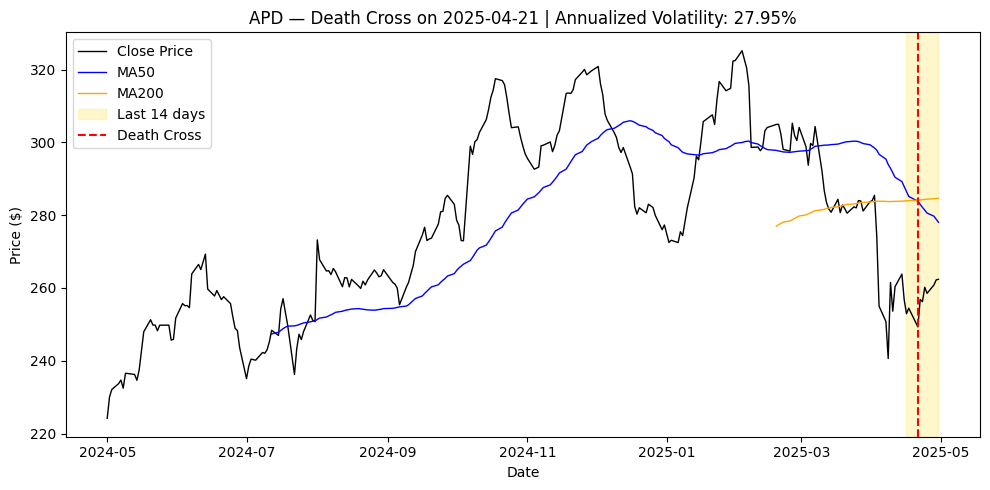

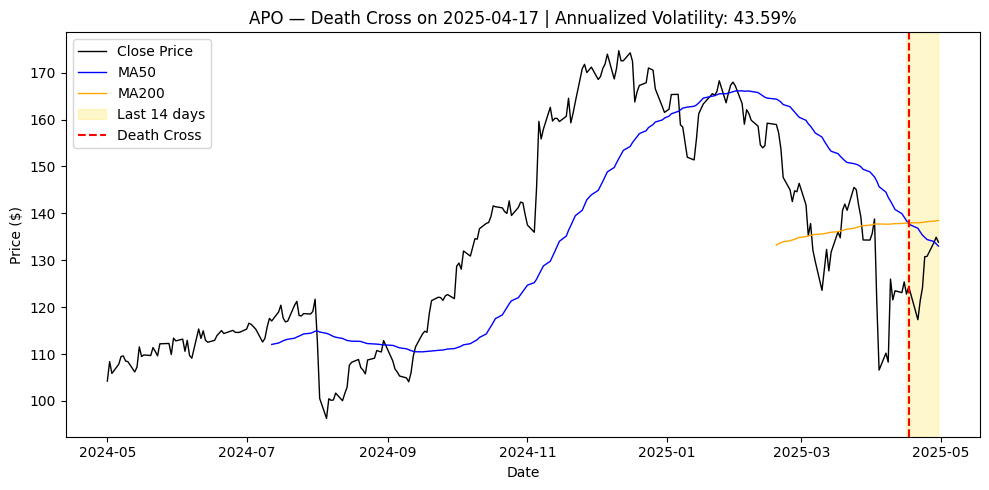

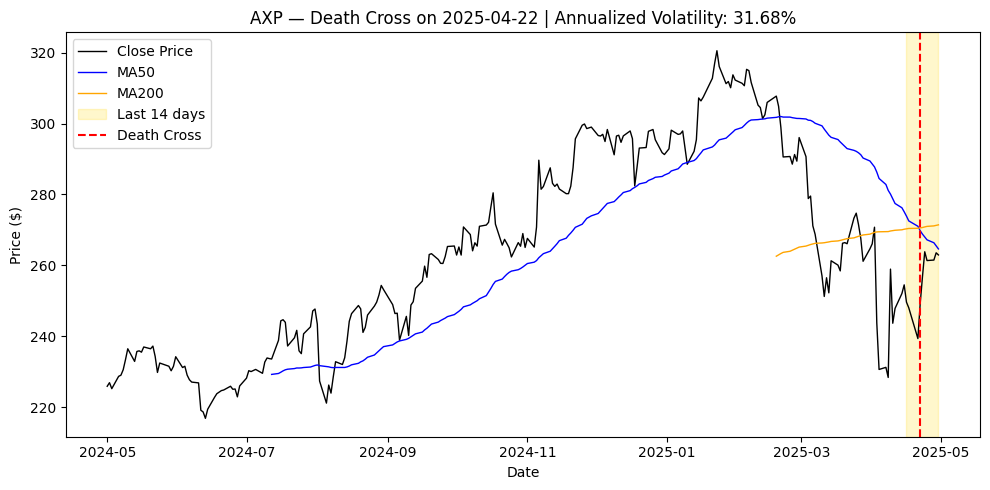

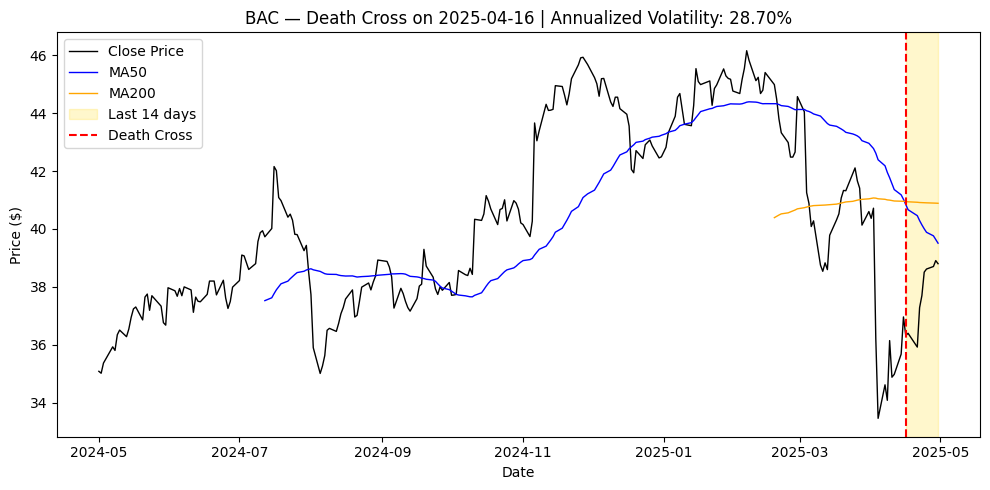

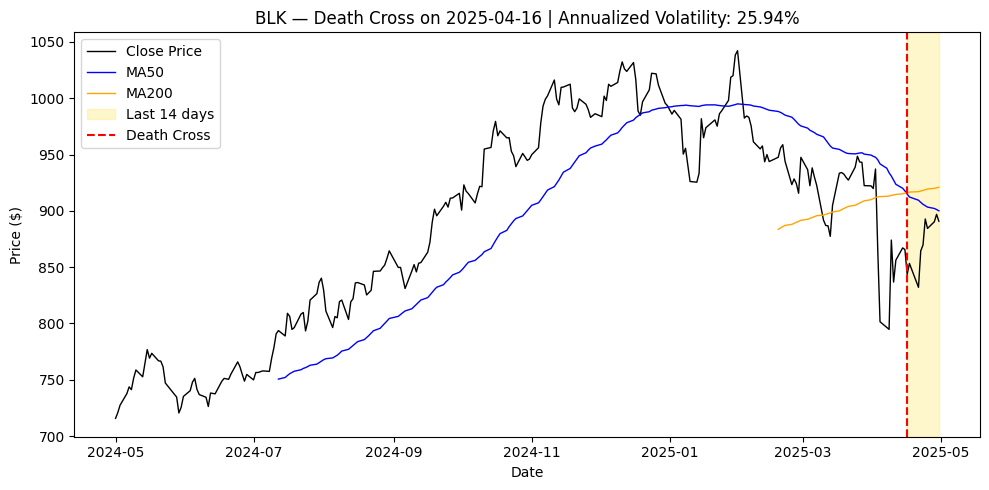

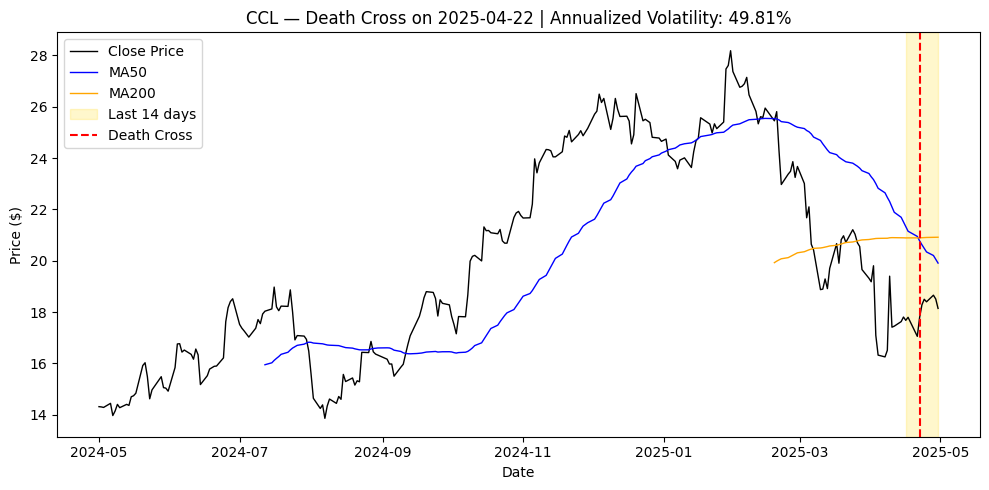

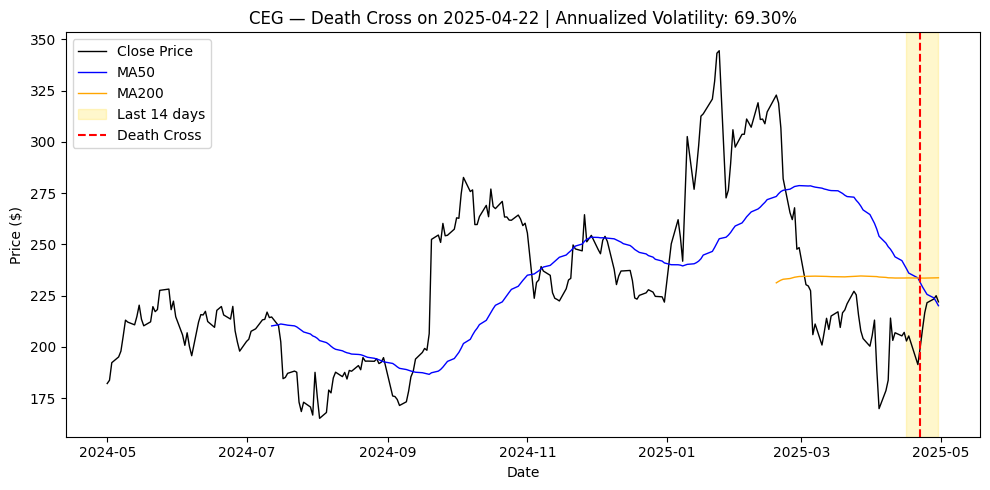

In [15]:
# CODE HERE
# Visualize the results here

top10_death = df_death_cross_14d.sort_values('Ticker').head(10)
last_date = df_close.index.max()
shade_start = last_date - pd.Timedelta(days=14)

for _, row in top10_death.iterrows():
    ticker = row['Ticker']
    cross_date = row['Cross Date']

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_close.index, df_close[ticker], label='Close Price', color='black', linewidth=1)
    ax.plot(df_ma50.index, df_ma50[ticker], label='MA50', color='blue', linewidth=1)
    ax.plot(df_ma200.index, df_ma200[ticker], label='MA200', color='orange', linewidth=1)

    # Shade the last 14 days
    ax.axvspan(shade_start, last_date, color='gold', alpha=0.2, label='Last 14 days')

    # Mark the exact cross date
    ax.axvline(cross_date, color='red', linestyle='--', linewidth=1.5, label='Death Cross')

    vol = volatility[ticker]
    ax.set_title(f'{ticker} — Death Cross on {cross_date.date()} | Annualized Volatility: {vol:.2%}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Question section

### Understanding concepts

#### What is a Golden Cross and what does it typically signal to investors?

A Golden Cross occurs when a stock's short-term moving average (MA50) crosses **above** its long-term moving average (MA200). It is traditionally interpreted as a bullish signal: it suggests that recent price momentum has strengthened enough to overtake the longer-term trend, and many traders read it as early confirmation that a sustained uptrend may be starting.



#### What is a Death Cross and how might market participants react to it?

A Death Cross is the opposite: it occurs when the MA50 crosses **below** the MA200. It is read as a bearish signal, implying that recent momentum has weakened relative to the long-term trend. Market participants often respond by reducing exposure, tightening stop-losses, or opening short positions, and the signal can attract media attention that amplifies selling pressure.



#### Why might moving averages (MA50, MA200) be used as indicators in technical analysis?

Moving averages smooth out the day-to-day noise in a price series, making the underlying trend easier to see. Comparing a short-term average (MA50) to a long-term average (MA200) captures *momentum* - whether recent prices are strengthening or weakening relative to the broader trend. They are also simple, transparent, and widely followed by other traders, which makes crossovers somewhat self-fulfilling: enough market participants act on the same signal that it can influence price action.



#### Why are the last 14 days used to check for crosses? What are the implications of this choice?

A 14-day window keeps the signal timely and actionable - it surfaces crosses that are recent enough for a trader to still act on, rather than reviewing crosses from months ago where any resulting move has likely already played out. The trade-off is that it's an arbitrary cutoff: a cross on day 14 has had time to be "confirmed" by subsequent price action, while one on day 1 is unconfirmed and could still reverse. It also risks survivorship-style bias by excluding crosses that happened just outside the window even if they are still relevant.



#### How does volatility (e.g., measured using percentage change standard deviation) help contextualize the price movement around crosses?

Volatility (e.g., the standard deviation of daily returns, annualized) tells you how noisy a stock's price action is. A Golden Cross on a low-volatility stock is more likely to reflect a genuine, durable shift in trend, while the same signal on a high-volatility stock could just be noise or a "whipsaw" that reverses quickly. Pairing the cross with volatility helps a trader judge how much confidence to place in the signal and how to size a position or set a stop-loss around it.


### Backtesting and evaluation

#### How would you measure whether Golden Crosses actually lead to profitable trades?

I'd run a backtest: for every historical Golden Cross across the S&P 500 (not just the most recent 14 days), measure the stock's forward return over fixed horizons (e.g., 1 week, 1 month, 3 months) after the cross date. I'd then compare the average forward return and win rate (% of crosses followed by a positive return) against a benchmark - either a buy-and-hold return over the same period or a random entry-date control - and compute a risk-adjusted metric like the Sharpe ratio. Running the same test on Death Crosses (checking for negative forward returns) would test the strategy symmetrically. A statistically significant, consistent edge over many crosses and many stocks (not just a handful of examples) is what would make the pattern more than a coincidence.


#### What are the risks of using only technical indicators like moving averages without incorporating fundamentals?

Moving averages say nothing about a company's earnings, balance sheet, competitive position, or upcoming events (M&A, litigation, product launches). A stock can produce a "textbook" Golden Cross right before an earnings miss or a regulatory setback, and the indicator will not see it coming. Technical signals are also inherently lagging (they are built from past prices), can generate frequent false positives in sideways/choppy markets, and can become a self-fulfilling but crowded trade if too many participants react to the same signal at once, amplifying volatility rather than reflecting real value.


#### How would you improve this strategy to reduce false signals (e.g., a Golden Cross that doesn’t lead to a price increase)?

A few ways to reduce false positives: (1) require confirmation, e.g. only count a cross if the MA50 stays above the MA200 for several additional days, or if price also breaks above a recent resistance level; (2) filter by volume, since a cross on unusually high trading volume is more credible than one on thin volume; (3) combine with other indicators like RSI or MACD to avoid acting on a single signal in isolation; (4) filter out low-volatility "grinding" crosses versus high-volatility "spike" crosses depending on the strategy's risk tolerance; and (5) backtest different lookback windows and MA lengths to find parameters that historically reduce whipsaws for a given universe of stocks.


### AI Integration


#### Could sentiment from news (future project part) help validate or invalidate these technical signals?

Yes - news sentiment could act as a confirming or contradicting filter. A Golden Cross that coincides with positive sentiment (strong earnings, favorable guidance, positive analyst coverage) would give more confidence that the trend has real underlying support. Conversely, a bullish technical cross alongside negative or deteriorating sentiment would be a warning sign that the move may not hold, since something the moving averages can't see (an earnings miss, a lawsuit, a guidance cut) may be about to reverse the trend. Combining the two turns a single-factor technical signal into a more robust, multi-factor one.


### Critical thinking

#### From a trading perspective, is this strategy actionable on its own?

Not really on its own. It is a useful watchlist generator - a fast way to screen hundreds of stocks for ones exhibiting a specific momentum pattern - but it lacks risk management (position sizing, stop-losses), is lagging by construction, and ignores fundamentals and news. In practice this kind of signal is best used as one filter among several, combined with other indicators, fundamental screening, and a defined risk plan, rather than as a standalone buy/sell trigger.


#### Based on the volatility observed post-Golden Cross, do these crosses consistently predict upward movement?

*Fill in after running the volatility and cross-detection cells above.* In general, expect a mixed picture: some Golden Cross stocks with low-to-moderate volatility will show a steadier, more consistent upward drift after the cross, while high-volatility names are more likely to show choppy or reversed price action shortly after the signal. That pattern would suggest that Golden Crosses do not *consistently* predict upward movement on their own - volatility context matters, and the signal is more reliable as one input rather than a guarantee.



#### If you had to present this analysis to a portfolio manager, what conclusions would you emphasize? What caveats would you include?

Conclusions in 2 bullet points:

- *(Fill in with your results)* e.g., "X% of the S&P 500 stocks with a Golden Cross in the last 14 days also had below-median volatility, suggesting a comparatively stable set of momentum candidates worth further fundamental review."
- *(Fill in with your results)* e.g., "Death Cross names skewed toward higher volatility, consistent with the idea that sharp momentum breakdowns tend to come with elevated price swings."

Caveats in 2 or 3 bullet points:

- This is a purely technical, backward-looking screen; it does not account for fundamentals, upcoming earnings, or macro catalysts that could invalidate the pattern.
- A 14-day lookback and MA50/MA200 crossover is one specific, somewhat arbitrary parameterization; results would likely change with different windows or additional confirmation filters.
- Without a formal backtest of forward returns, we cannot yet claim these crosses reliably predict future price direction - they should be treated as a starting watchlist, not a trading signal on their own.
